# 🍵 Tea Garden Climate Risk Analyzer
## Model Training — Stress Level & Risk Level Classification

This notebook:
- Trains **Random Forest**, **Decision Tree**, and **Logistic Regression** for stress & risk classification
- Compares all models by accuracy and macro F1
- Plots confusion matrices and feature importances
- Serializes the best model for use in the Streamlit app

## 1. Imports

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13})

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "Data").exists() or not (PROJECT_ROOT / "Figures").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "Data" / "Indian_Climate_Dataset_2024_2025.csv"
FIGURES_DIR = PROJECT_ROOT / "Figures"
DATA_OUTPUT_DIR = PROJECT_ROOT / "data"


os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(DATA_OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42
print("Setup complete ✔")

Setup complete ✔


## 2. Load Cleaned Dataset

In [3]:
DATA_PATH = PROJECT_ROOT / "Data" / "climate_clean_labeled.csv"
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print("Stress distribution:\n", df["stress_level"].value_counts())
print("Risk distribution:\n",   df["risk_level"].value_counts())
df.head(3)

Shape: (7310, 25)
Stress distribution:
 stress_level
Severe Stress    3508
Mild Stress      3027
Healthy           775
Name: count, dtype: int64
Risk distribution:
 risk_level
High        3376
Extreme     2279
Moderate    1250
Low          405
Name: count, dtype: int64


,date,state,city,avg_temperature,rainfall,humidity,wind_speed,cloud_cover,aqi,year,...,season,avg_temperature_roll7,rainfall_roll7,humidity_roll7,avg_temperature_dev,rainfall_dev,humidity_dev,csi,stress_level,risk_level
0,2024-01-01,Gujarat,Ahmedabad,32.8,0.0,83.9,5.2,12.1,345,2024,...,Winter,32.800000,0.000000,83.900000,0.000000,0.000000,0.000000,8,Severe Stress,Extreme
1,2024-01-02,Gujarat,Ahmedabad,32.4,5.4,71.2,9.4,8.9,223,2024,...,Winter,32.600000,2.700000,77.550000,-0.200000,2.700000,-6.350000,4,Mild Stress,High
2,2024-01-03,Gujarat,Ahmedabad,37.3,5.2,39.1,18.0,39.2,131,2024,...,Winter,34.166667,3.533333,64.733333,3.133333,1.666667,-25.633333,4,Mild Stress,High


## 3. Feature & Target Selection

In [4]:
# Core features available in both training and the Streamlit live-input panel
BASE_FEATURES = [
    "avg_temperature",
    "rainfall",
    "humidity",
    "wind_speed",
    "cloud_cover",
    "aqi",
    "month",
    "week",
]

# Optional engineered features (add if present)
EXTRA_FEATURES = [
    "month_sin", "month_cos", "day_of_year",
    "avg_temperature_roll7", "rainfall_roll7", "humidity_roll7",
    "avg_temperature_dev",   "rainfall_dev",   "humidity_dev",
]

FEATURES = BASE_FEATURES + [f for f in EXTRA_FEATURES if f in df.columns]

print(f"Using {len(FEATURES)} features:")
print(FEATURES)

Using 17 features:
['avg_temperature', 'rainfall', 'humidity', 'wind_speed', 'cloud_cover', 'aqi', 'month', 'week', 'month_sin', 'month_cos', 'day_of_year', 'avg_temperature_roll7', 'rainfall_roll7', 'humidity_roll7', 'avg_temperature_dev', 'rainfall_dev', 'humidity_dev']


In [5]:
X = df[FEATURES]

# Encode both targets
le_stress = LabelEncoder()
le_risk   = LabelEncoder()

y_stress = le_stress.fit_transform(df["stress_level"])
y_risk   = le_risk.fit_transform(df["risk_level"])

print("Stress classes:", dict(zip(le_stress.classes_, le_stress.transform(le_stress.classes_))))
print("Risk classes:  ", dict(zip(le_risk.classes_,   le_risk.transform(le_risk.classes_))))

Stress classes: {'Healthy': np.int64(0), 'Mild Stress': np.int64(1), 'Severe Stress': np.int64(2)}
Risk classes:   {'Extreme': np.int64(0), 'High': np.int64(1), 'Low': np.int64(2), 'Moderate': np.int64(3)}


## 4. Train–Test Split

In [6]:
X_tr, X_te, ys_tr, ys_te = train_test_split(
    X, y_stress, test_size=0.2, random_state=RANDOM_STATE, stratify=y_stress
)
_, _,    yr_tr, yr_te = train_test_split(
    X, y_risk,   test_size=0.2, random_state=RANDOM_STATE, stratify=y_risk
)

print(f"Train: {X_tr.shape[0]} rows  |  Test: {X_te.shape[0]} rows")

Train: 5848 rows  |  Test: 1462 rows


## 5. Helper: Evaluation & Plotting

In [7]:
def evaluate(name: str, model, X_tr, y_tr, X_te, y_te, le, cv: int = 5):
    """Fit, evaluate with CV + hold-out, return metrics dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, average="macro")

    cv_scores = cross_val_score(
        model, X_tr, y_tr, cv=StratifiedKFold(cv, shuffle=True, random_state=42),
        scoring="accuracy", n_jobs=-1
    )

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Macro F1 : {f1:.4f}")
    print(f"  CV Acc   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(classification_report(y_te, y_pred, target_names=le.classes_))

    return {"name": name, "model": model, "acc": acc, "f1": f1,
            "cv_mean": cv_scores.mean(), "cv_std": cv_scores.std(),
            "y_pred": y_pred}


def plot_cm(results: dict, y_te, le, title_prefix: str, fname: str):
    """Side-by-side confusion matrices for all trained models."""
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, (name, res) in zip(axes, results.items()):
        cm = confusion_matrix(y_te, res["y_pred"])
        disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"{name}\nAcc={res['acc']:.3f}  F1={res['f1']:.3f}")
        ax.tick_params(axis="x", rotation=25)

    plt.suptitle(f"{title_prefix} — Confusion Matrices", fontsize=14, y=1.02)
    plt.tight_layout()
    output_path = FIGURES_DIR / fname
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, bbox_inches="tight")
    plt.show()

---
## 6. Stress Level Classification

In [8]:
stress_models_def = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            multi_class="multinomial"
        ))
    ])
}

stress_results = {}
for name, mdl in stress_models_def.items():
    stress_results[name] = evaluate(
        name, mdl, X_tr, ys_tr, X_te, ys_te, le_stress
    )


  Random Forest
  Accuracy : 0.9631
  Macro F1 : 0.9575
  CV Acc   : 0.9458 ± 0.0107
               precision    recall  f1-score   support

      Healthy       0.94      0.95      0.94       155
  Mild Stress       0.94      0.98      0.96       605
Severe Stress       0.99      0.96      0.97       702

     accuracy                           0.96      1462
    macro avg       0.96      0.96      0.96      1462
 weighted avg       0.96      0.96      0.96      1462


  Decision Tree
  Accuracy : 0.9822
  Macro F1 : 0.9776
  CV Acc   : 0.9752 ± 0.0031
               precision    recall  f1-score   support

      Healthy       0.95      0.98      0.97       155
  Mild Stress       0.98      0.98      0.98       605
Severe Stress       0.99      0.99      0.99       702

     accuracy                           0.98      1462
    macro avg       0.97      0.98      0.98      1462
 weighted avg       0.98      0.98      0.98      1462


  Logistic Regression
  Accuracy : 0.7456
  Macro F

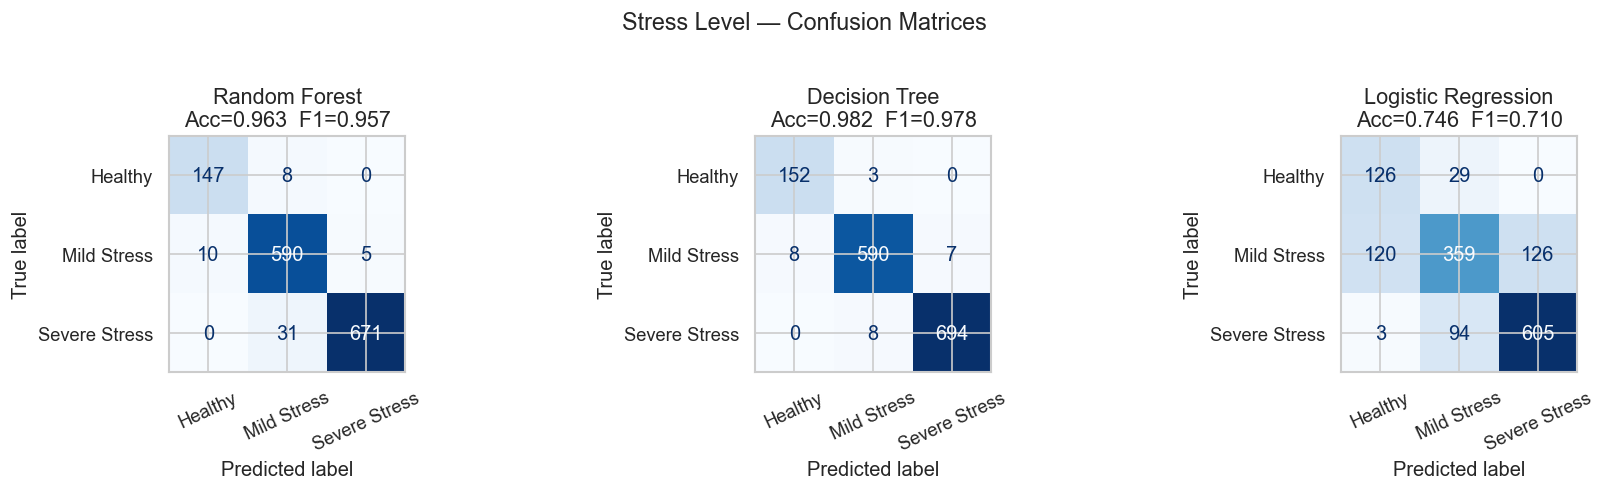

In [9]:
plot_cm(stress_results, ys_te, le_stress,
        title_prefix="Stress Level", fname="07_stress_confusion_matrices.png")

## 7. Risk Level Classification

In [18]:
risk_models_def = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            multi_class="multinomial"
        ))
    ])
}

risk_results = {}
for name, mdl in risk_models_def.items():
    risk_results[name] = evaluate(
        name, mdl, X_tr, yr_tr, X_te, yr_te, le_risk
    )


  Random Forest
  Accuracy : 0.4419
  Macro F1 : 0.2004
  CV Acc   : 0.4359 ± 0.0088
              precision    recall  f1-score   support

     Extreme       0.31      0.13      0.18       456
        High       0.46      0.87      0.60       675
         Low       0.00      0.00      0.00        81
    Moderate       0.25      0.01      0.02       250

    accuracy                           0.44      1462
   macro avg       0.26      0.25      0.20      1462
weighted avg       0.35      0.44      0.34      1462


  Decision Tree
  Accuracy : 0.2018
  Macro F1 : 0.1887
  CV Acc   : 0.2640 ± 0.0360
              precision    recall  f1-score   support

     Extreme       0.34      0.13      0.19       456
        High       0.47      0.15      0.23       675
         Low       0.06      0.28      0.09        81
    Moderate       0.16      0.43      0.24       250

    accuracy                           0.20      1462
   macro avg       0.26      0.25      0.19      1462
weighted avg 

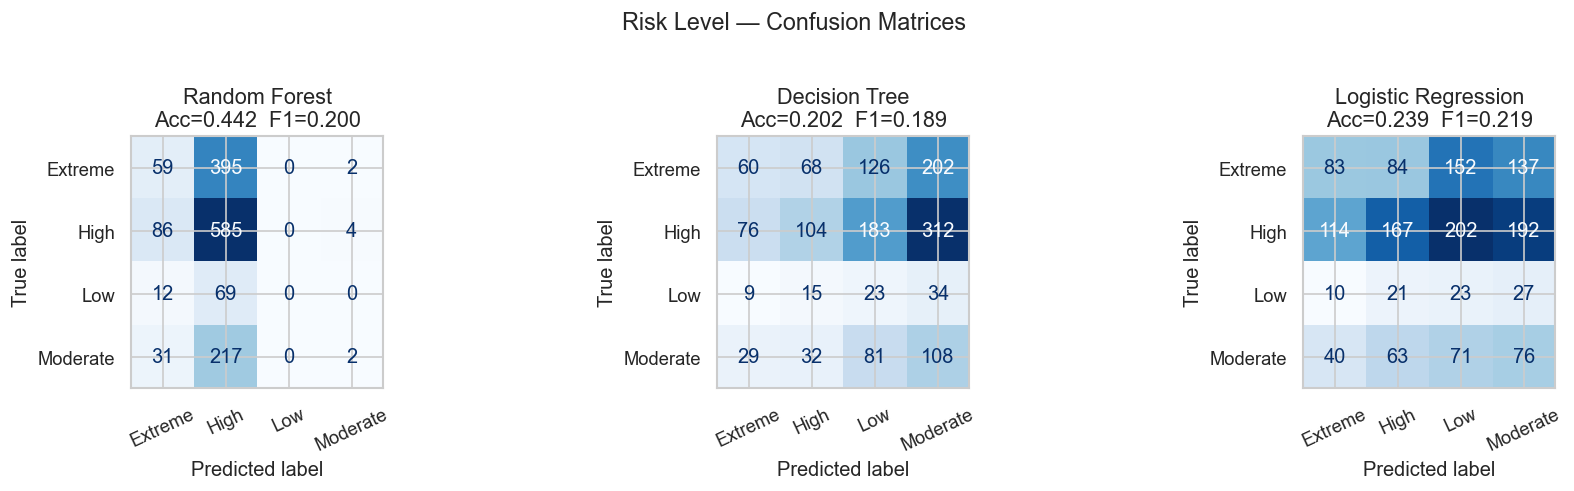

In [11]:
plot_cm(risk_results, yr_te, le_risk,
        title_prefix="Risk Level", fname="08_risk_confusion_matrices.png")

## 8. Model Comparison

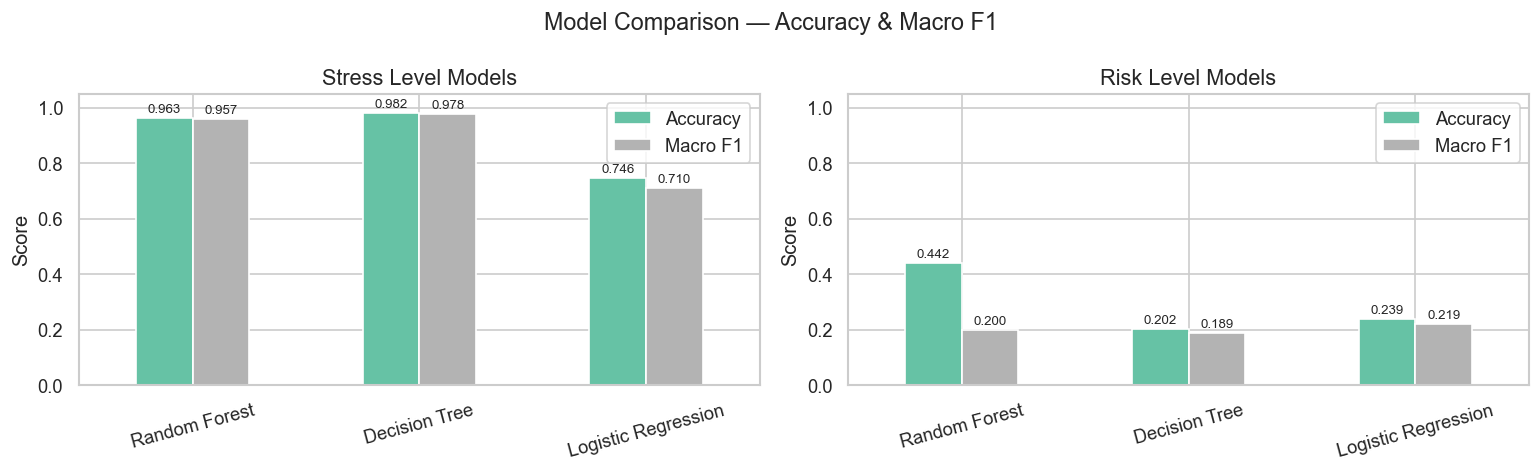


Stress models:
                     Accuracy  Macro F1   CV Mean    CV Std
Model                                                      
Random Forest        0.963064  0.957474  0.945791  0.010742
Decision Tree        0.982216  0.977610  0.975205  0.003058
Logistic Regression  0.745554  0.709559  0.729990  0.010590

Risk models:
                     Accuracy  Macro F1   CV Mean    CV Std
Model                                                      
Random Forest        0.441860  0.200379  0.435875  0.008786
Decision Tree        0.201778  0.188667  0.264013  0.036027
Logistic Regression  0.238714  0.219164  0.223837  0.015147


In [17]:
def comparison_df(results: dict) -> pd.DataFrame:
    rows = []
    for name, r in results.items():
        rows.append({
            "Model":   name,
            "Accuracy": r["acc"],
            "Macro F1": r["f1"],
            "CV Mean":  r["cv_mean"],
            "CV Std":   r["cv_std"]
        })
    return pd.DataFrame(rows).set_index("Model")

stress_cmp = comparison_df(stress_results)
risk_cmp   = comparison_df(risk_results)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, cmp, title in zip(
    axes,
    [stress_cmp, risk_cmp],
    ["Stress Level Models", "Risk Level Models"]
):
    cmp[["Accuracy", "Macro F1"]].plot(
        kind="bar", ax=ax, rot=15, colormap="Set2", edgecolor="white"
    )
    ax.set_ylim(0, 1.05)
    ax.set_title(title)
    ax.set_ylabel("Score")
    ax.set_xlabel("")
    ax.legend(loc="upper right")
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.3f}",
                    (p.get_x() + p.get_width() / 2, p.get_height() + 0.01),
                    ha="center", va="bottom", fontsize=8)

plt.suptitle("Model Comparison — Accuracy & Macro F1", fontsize=14)
plt.tight_layout()

output_path = FIGURES_DIR 
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path/"09_model_comparison.png")
plt.show()

print("\nStress models:")
print(stress_cmp.to_string())
print("\nRisk models:")
print(risk_cmp.to_string())

## 9. Feature Importance (Random Forest)

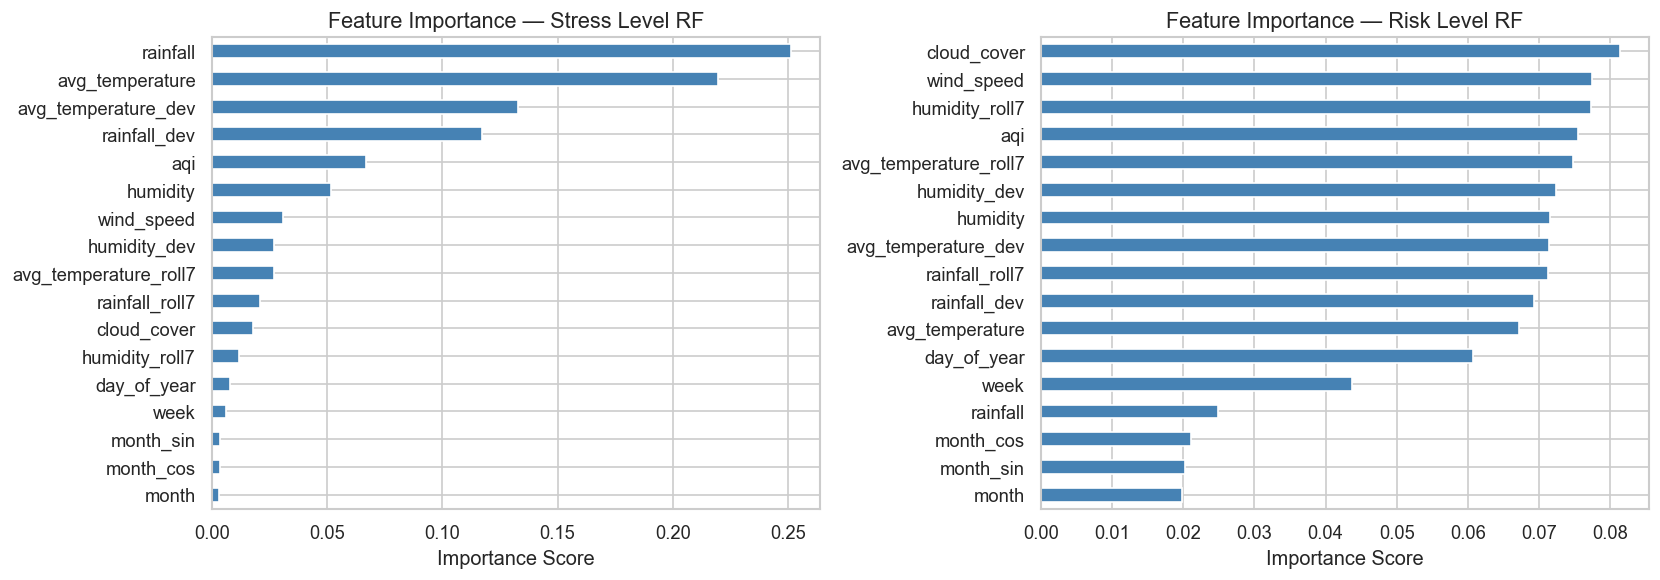

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, results, title in zip(
    axes,
    [stress_results, risk_results],
    ["Stress Level", "Risk Level"]
):
    rf_model = results["Random Forest"]["model"]
    # Handle Pipeline vs direct model
    if hasattr(rf_model, "feature_importances_"):
        importances = rf_model.feature_importances_
    else:
        importances = rf_model.named_steps["clf"].coef_[0]

    imp_series = pd.Series(importances, index=FEATURES).sort_values(ascending=True)
    imp_series.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"Feature Importance — {title} RF")
    ax.set_xlabel("Importance Score")

plt.tight_layout()

output_path = FIGURES_DIR 
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path/"10_feature_importances.png")
plt.show()

## 10. Save Best Models

In [15]:
# Pick best model for each task by accuracy
best_stress_name = max(stress_results, key=lambda k: stress_results[k]["acc"])
best_risk_name   = max(risk_results,   key=lambda k: risk_results[k]["acc"])

best_stress = stress_results[best_stress_name]["model"]
best_risk   = risk_results[best_risk_name]["model"]

print(f"Best stress model  : {best_stress_name}  "
      f"(acc={stress_results[best_stress_name]['acc']:.4f})")
print(f"Best risk model    : {best_risk_name}  "
      f"(acc={risk_results[best_risk_name]['acc']:.4f})")

# Serialize
models_dir = PROJECT_ROOT / "Model"
models_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(best_stress, models_dir / "tea_stress_model.pkl")
joblib.dump(best_risk,   models_dir / "tea_risk_model.pkl")
joblib.dump(le_stress,   models_dir / "le_stress.pkl")
joblib.dump(le_risk,     models_dir / "le_risk.pkl")
joblib.dump(FEATURES,    models_dir / "feature_names.pkl")

print("\nAll models and encoders saved to Model/ ✔")

Best stress model  : Decision Tree  (acc=0.9822)
Best risk model    : Random Forest  (acc=0.4419)

All models and encoders saved to Model/ ✔


## 11. Summary Table

In [16]:
summary = []
for task, results, le in [
    ("Stress", stress_results, le_stress),
    ("Risk",   risk_results,   le_risk)
]:
    for name, r in results.items():
        summary.append({
            "Task":     task,
            "Model":    name,
            "Accuracy": f"{r['acc']:.4f}",
            "Macro F1": f"{r['f1']:.4f}",
            "CV Mean":  f"{r['cv_mean']:.4f} ± {r['cv_std']:.4f}"
        })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

  Task               Model Accuracy Macro F1         CV Mean
Stress       Random Forest   0.9631   0.9575 0.9458 ± 0.0107
Stress       Decision Tree   0.9822   0.9776 0.9752 ± 0.0031
Stress Logistic Regression   0.7456   0.7096 0.7300 ± 0.0106
  Risk       Random Forest   0.4419   0.2004 0.4359 ± 0.0088
  Risk       Decision Tree   0.2018   0.1887 0.2640 ± 0.0360
  Risk Logistic Regression   0.2387   0.2192 0.2238 ± 0.0151
